# Data Understanding:Telco Customer Churn

After defining the business problem and the project goals, the next step is to explore the raw data.

The goal of this phase is simple: to understand the dataset, check its quality, and identify potential issues before preparing the data and building machine learning models.

In [180]:
import pandas as pd
import matplotlib.pyplot as plt

In [181]:
df_services = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_status = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

df_services = df_services.rename(columns={"customerID": "Customer ID"})
df_raw = df_services.merge(df_status, on="Customer ID", how="inner", validate="1:1")

## Dataset Overview

In [182]:
df_raw.head(10)

,Customer ID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Count,Quarter,Satisfaction Score,Customer Status,Churn Label,Churn Value,Churn Score,CLTV,Churn Category,Churn Reason
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,1,Q3,3,Joined,No,0,27,3964,NaN,NaN
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,1,Q3,3,Stayed,No,0,61,3441,NaN,NaN
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,1,Q3,1,Churned,Yes,1,86,3239,Competitor,Competitor made better offer
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,1,Q3,3,Stayed,No,0,66,4307,NaN,NaN
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,1,Q3,2,Churned,Yes,1,67,2701,Other,Moved
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,1,Q3,3,Churned,Yes,1,86,5372,Other,Moved
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,1,Q3,4,Stayed,No,0,43,4459,NaN,NaN
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,1,Q3,3,Stayed,No,0,51,2013,NaN,NaN
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,1,Q3,3,Churned,Yes,1,84,5003,Other,Moved
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,1,Q3,4,Stayed,No,0,58,4529,NaN,NaN


In [183]:
df_raw.dtypes.value_counts()

str        23
int64       7
float64     1
Name: count, dtype: int64

## Data Dimensions

In [184]:
df_raw.shape

(7043, 31)

## Feature Types

In [185]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer ID         7043 non-null   str    
 1   gender              7043 non-null   str    
 2   SeniorCitizen       7043 non-null   int64  
 3   Partner             7043 non-null   str    
 4   Dependents          7043 non-null   str    
 5   tenure              7043 non-null   int64  
 6   PhoneService        7043 non-null   str    
 7   MultipleLines       7043 non-null   str    
 8   InternetService     7043 non-null   str    
 9   OnlineSecurity      7043 non-null   str    
 10  OnlineBackup        7043 non-null   str    
 11  DeviceProtection    7043 non-null   str    
 12  TechSupport         7043 non-null   str    
 13  StreamingTV         7043 non-null   str    
 14  StreamingMovies     7043 non-null   str    
 15  Contract            7043 non-null   str    
 16  PaperlessBilling 

Deux colonnes sont constantes sur l'ensemble des 7043 lignes et n'apportent aucune information 

In [186]:
df_raw["Count"].unique()
df_raw["Quarter"].unique()

<StringArray>
['Q3']
Length: 1, dtype: str

`Count` and `Quarter` will be considered for removal during the Data Preparation phase.

In [187]:
df_raw.describe()

,SeniorCitizen,tenure,MonthlyCharges,Count,Satisfaction Score,Churn Value,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.0,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,1.0,3.244924,0.265370,58.505040,4400.295755
std,0.368612,24.559481,30.090047,0.0,1.201657,0.441561,21.170031,1183.057152
min,0.000000,0.000000,18.250000,1.0,1.000000,0.000000,5.000000,2003.000000
25%,0.000000,9.000000,35.500000,1.0,3.000000,0.000000,40.000000,3469.000000
50%,0.000000,29.000000,70.350000,1.0,3.000000,0.000000,61.000000,4527.000000
75%,0.000000,55.000000,89.850000,1.0,4.000000,1.000000,75.500000,5380.500000
max,1.000000,72.000000,118.750000,1.0,5.000000,1.000000,96.000000,6500.000000


## Missing Values

In [188]:
df_raw.isna().sum()

Customer ID              0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges             0
Churn                    0
Count                    0
Quarter                  0
Satisfaction Score       0
Customer Status          0
Churn Label              0
Churn Value              0
Churn Score              0
CLTV                     0
Churn Category        5174
Churn Reason          5174
dtype: int64

`Churn Category` and `Churn Reason` are only populated for customers who actually churned. The 5,174 missing values exactly match the number of customers with `Churn = "No"`, meaning these fields are intentionally left empty for customers who stayed.

In [189]:
for col in df_raw.select_dtypes(include="object").columns:
    blank = df_raw[col].astype(str).str.strip().eq("").sum()
    if blank > 0:
        print(col, blank)

TotalCharges 11


/tmp/ipykernel_9881/1212301590.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_raw.select_dtypes(include="object").columns:


`TotalCharges` is stored as text and contains 11 blank values that are not detected by `isna()`. When compared with `tenure`, these 11 records all correspond to customers with `tenure = 0`, meaning they are new customers who have not yet received their first bill. Therefore, these are not true missing values, but rather a logical absence of billing.

## Duplicate Records

In [190]:
df_raw.duplicated().sum()

np.int64(0)

## Satisfaction Score

In [191]:
df_raw["Satisfaction Score"].value_counts().sort_index()
df_raw["Satisfaction Score"].value_counts(normalize=True).sort_index() * 100

Satisfaction Score
1    13.091012
2     7.354820
3    37.838989
4    25.401107
5    16.314071
Name: proportion, dtype: float64

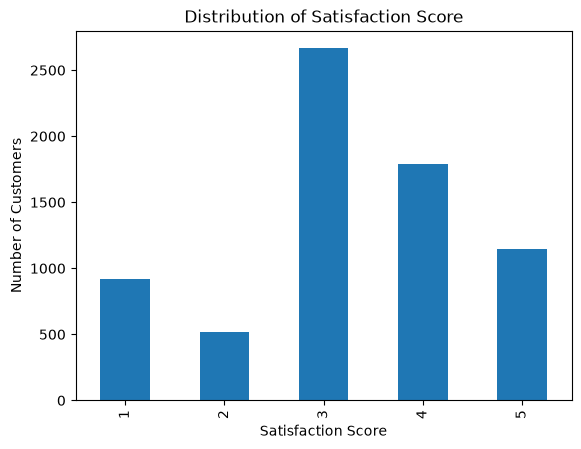

In [192]:
df_raw["Satisfaction Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Number of Customers")
plt.show()

The distribution is clearly centered around score 3 (37.8% of customers), with a gradual decrease towards the extremes.  

An important point for the next steps is that the way these 5 levels are grouped into 3 NPS categories (Data Preparation) will strongly influence the balance of the final target. A mapping that classifies score 3 as a "Detractor" would lead to a highly imbalanced target, whereas a mapping that assigns it to "Passive" would result in a distribution that is more consistent with a realistic NPS structure.

## Data Leakage Risk Assessment

In [193]:
df_raw.groupby("Satisfaction Score")["Churn Value"].mean() * 100

Satisfaction Score
1    100.000000
2    100.000000
3     16.097561
4      0.000000
5      0.000000
Name: Churn Value, dtype: float64

In [194]:
df_raw.groupby("Satisfaction Score")["Churn Score"].mean()

Satisfaction Score
1    81.735358
2    82.092664
3    55.000750
4    50.148686
5    50.369017
Name: Churn Score, dtype: float64

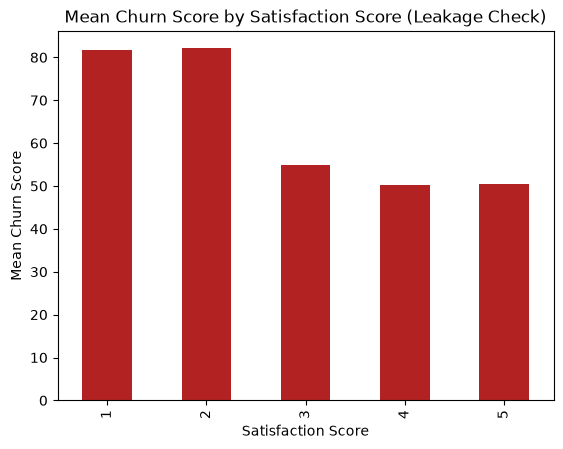

In [195]:
df_raw.groupby("Satisfaction Score")["Churn Score"].mean().plot(kind="bar", color="firebrick")
plt.title("Mean Churn Score by Satisfaction Score (Leakage Check)")
plt.xlabel("Satisfaction Score")
plt.ylabel("Mean Churn Score")
plt.show()

The relationship is almost deterministic: a satisfaction score of 1 or 2 corresponds to a 100% churn rate, while scores of 4 or 5 correspond to 0% churn. The `Churn Score` follows a similar continuous pattern.

This is consistent with the fact that both variables were likely computed or collected in direct relation to customer experience measured by the `Satisfaction Score`. Using them as input features to predict NPS would therefore introduce data leakage, as they would implicitly contain a transformed version of the target information.

In [196]:
df_raw.groupby("Satisfaction Score")["CLTV"].mean()

Satisfaction Score
1    4158.219089
2    4104.393822
3    4473.402627
4    4514.324203
5    4380.839861
Name: CLTV, dtype: float64

The link is almost deterministic: a satisfaction score of 1 or 2 leads to a 100% churn rate, while a score of 4 or 5 leads to 0% churn.

The `Churn Score` follows the same continuous pattern.
This is consistent with the fact that these two variables were likely created or collected in direct relation with customer experience measured by the `Satisfaction Score`.
Using them as input features to predict NPS would cause data leakage, because they already contain information very close to the target.

## Key Feature Relationships

In [197]:
df_raw.groupby("Contract")["Satisfaction Score"].mean()

Contract
Month-to-month    2.936516
One year          3.563476
Two year          3.673156
Name: Satisfaction Score, dtype: float64

In [198]:
df_raw.groupby("InternetService")["Satisfaction Score"].mean()

InternetService
DSL            3.291202
Fiber optic    2.910853
No             3.849279
Name: Satisfaction Score, dtype: float64

In [199]:
df_raw.groupby("PaymentMethod")["Satisfaction Score"].mean()

PaymentMethod
Bank transfer (automatic)    3.426166
Credit card (automatic)      3.436268
Electronic check             2.870190
Mailed check                 3.440447
Name: Satisfaction Score, dtype: float64

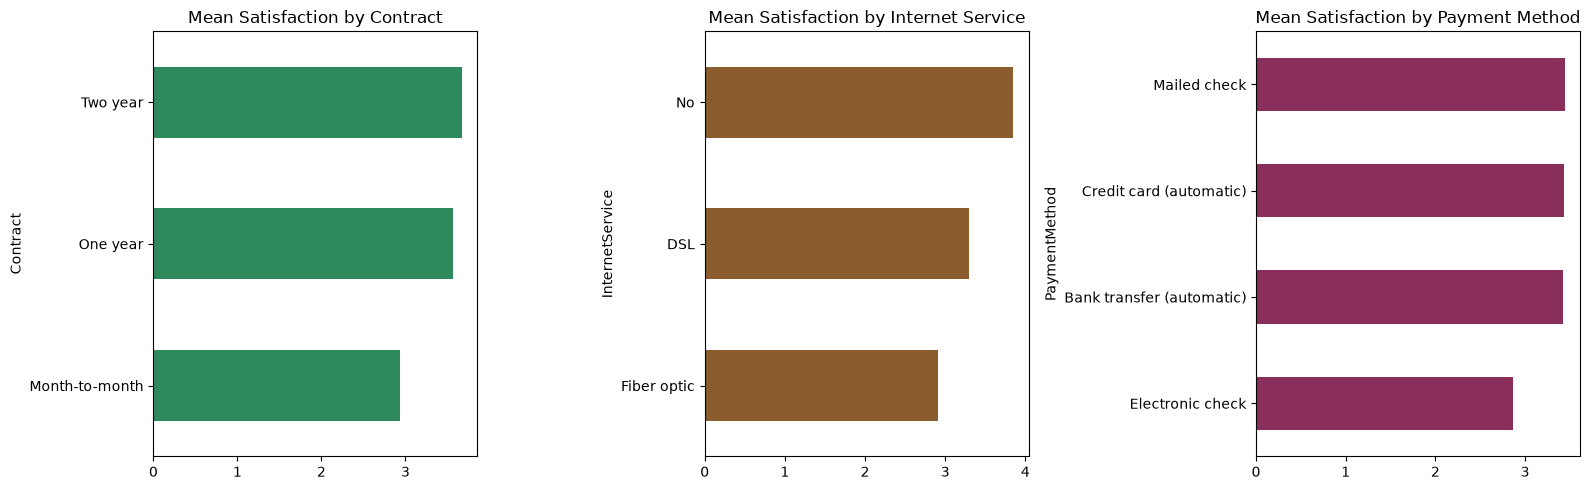

In [200]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
df_raw.groupby("Contract")["Satisfaction Score"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#2E8A5C")
axes[0].set_title("Mean Satisfaction by Contract")
df_raw.groupby("InternetService")["Satisfaction Score"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#8A5C2E")
axes[1].set_title("Mean Satisfaction by Internet Service")
df_raw.groupby("PaymentMethod")["Satisfaction Score"].mean().sort_values().plot(kind="barh", ax=axes[2], color="#8A2E5C")
axes[2].set_title("Mean Satisfaction by Payment Method")
plt.tight_layout()
plt.show()

Three clear and actionable patterns emerge: contract engagement, internet service type, and payment method are all linked to customer satisfaction. These patterns are consistent with the findings from the churn analysis. Customers with month-to-month contracts, fiber optic internet, and electronic check payments are associated with lower satisfaction levels.

In [218]:
df_raw.groupby("Satisfaction Score")["tenure"].mean()
df_raw.groupby("Satisfaction Score")["MonthlyCharges"].mean()

Satisfaction Score
1    75.814588
2    73.464865
3    66.231932
4    61.906260
5    53.004656
Name: MonthlyCharges, dtype: float64

`MonthlyCharges` decreases steadily with satisfaction: customers who pay higher prices tend to be less satisfied.

`tenure`, however, is not monotonic (long-term customers are not necessarily more satisfied). The relationship is likely more complex when combined with other variables, so it should be explored during modeling rather than only through univariate analysis.

## Preliminary Fairness Observation

In [ ]:
df_raw.groupby("SeniorCitizen")["Satisfaction Score"].mean()

In [219]:
pd.crosstab(df_raw["SeniorCitizen"], df_raw["Satisfaction Score"], normalize="index") * 100

Satisfaction Score,1,2,3,4,5
SeniorCitizen,,,,,
0,11.506524,6.744620,38.417217,26.249788,17.081851
1,21.278459,10.507881,34.851138,21.015762,12.346760


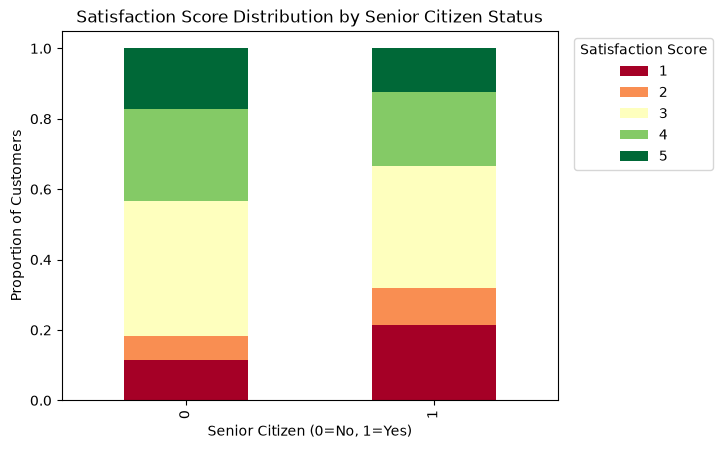

In [220]:
pd.crosstab(df_raw["SeniorCitizen"], df_raw["Satisfaction Score"], normalize="index").plot(
    kind="bar", stacked=True, colormap="RdYlGn"
)
plt.title("Satisfaction Score Distribution by Senior Citizen Status")
plt.xlabel("Senior Citizen (0=No, 1=Yes)")
plt.ylabel("Proportion of Customers")
plt.legend(title="Satisfaction Score", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Senior customers have a lower average satisfaction (2.93 vs 3.31) and are overrepresented in low scores (1–2).  

This is a valid demographic variable to keep as a feature, but the signal should be carefully monitored during the final model fairness audit (recall by group on the Detractor class).

## Conclusion

This phase allowed us to validate that the dataset is suitable for a machine learning project and to define a clear strategy for the next steps.

We confirmed that the data is generally clean, structured, and consistent enough to support predictive modeling. A few technical adjustments are required, particularly for variables with formatting issues and features that may introduce data leakage.

We also identified and removed early risks that could affect model reliability, such as variables derived from churn outcomes and non-informative fields.

From a methodological point of view, this phase helped establish a strong foundation for the project by:
- Clarifying the structure and scope of the dataset
- Identifying variables that must be excluded or transformed
- Highlighting key business signals that will guide feature engineering
- Preparing the transition toward a clean and modeling-ready dataset

As a result, we are now ready to move to the Data Preparation phase, where the focus will be on cleaning, transforming, and structuring the data for modeling.